# Sumativa 3 – Fase 4: Modelado Predictivo Integrado
## MCDI501: Estadística Computacional para la Toma de Decisiones
### Proyecto: Bank Marketing – Predicción de Suscripción a Depósito a Plazo

| Campo | Detalle |
|---|---|
| **Integrantes** | José Miguel Serrano · Jesús Fernández Urbaneja · Osvaldo Rodrigo Moncada Peralta · Evelyn Andrea Andrade Cárdenas |
| **Docente** | Jean Paul Maidana González |
| **Repositorio** | https://github.com/leofer23/formativa1-bank-marketing |
| **Fecha** | 25/06/2026 |

---
## Progresión metodológica S1 → S2 → S3

| Fase | Evaluación | Aporte a esta fase |
|---|---|---|
| S1 | Sumativa Fase 2 | EDA, IC Wilson, pruebas de hipótesis: poutcome (V=0.293), contact (V=0.139), balance (Mann-Whitney, d=0.061) |
| S2 | Sumativa Fase 3 | Bootstrap (1000 remuestras): poutcome estable IC=[0.247,0.338]; correlación pdays-previous robusta (r=0.578); Monte Carlo: priorizar poutcome=success genera +276 suscriptores/500 llamadas |
| S3 | **Esta evaluación** | Imputación por regresión, regresión logística (3 modelos), bootstrap de coeficientes, diagnóstico VIF, comparación de estrategias de imputación |

---
## Índice
1. [Carga de datos y resultados S1/S2](#s1)
2. [Parte 1: Imputación de datos faltantes](#p1)
3. [Parte 2: Regresión logística](#p2)
4. [Parte 3: Comparación del impacto de imputación](#p3)
5. [Conclusiones integradas S1→S2→S3](#conc)


In [1]:
# Instalacion de dependencias (ejecutar solo una vez, luego reiniciar kernel)
import sys
!{sys.executable} -m pip install numpy pandas matplotlib seaborn scipy scikit-learn --quiet
print("Librerias instaladas OK")


Librerias instaladas OK


## 1. Carga de datos y resultados S1/S2 <a id='s1'></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    roc_auc_score, roc_curve, f1_score, accuracy_score,
    recall_score, precision_score, confusion_matrix, ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

plt.rcParams.update({'figure.dpi':120,'axes.spines.top':False,
    'axes.spines.right':False,'axes.grid':True,'grid.alpha':0.3})
COLOR_SI='#1a6ea8'; COLOR_NO='#c0392b'; COLOR_NEU='#2c3e50'
print('Librerias cargadas OK')


Librerias cargadas OK


In [9]:
# Carga del dataset y resultados validados de S2
df = pd.read_csv('../S1/bank.csv', sep=';')
res_s2 = pd.read_csv('../S2/resultados_validados.csv')
print(f'Dataset: {df.shape[0]:,} filas x {df.shape[1]} columnas')
print(f'Resultados S2 cargados: {len(res_s2)} registros')
print()
print('=== Resultados clave de S2 usados en S3 ===')
key_s2 = res_s2[res_s2['parametro'].isin(['cramer_v_poutcome','cohen_d_duration',
    'mediana_balance','mediana_duration','pdays-previous'])]
print(key_s2[['parametro','estimacion','ic_low','ic_high','estabilidad']].to_string(index=False))


Dataset: 4,521 filas x 17 columnas
Resultados S2 cargados: 18 registros

=== Resultados clave de S2 usados en S3 ===
        parametro  estimacion     ic_low    ic_high                 estabilidad
  mediana_balance  444.000000 420.000000 474.000000                     robusto
 mediana_duration  185.000000 179.000000 192.000000                     robusto
 cohen_d_duration    1.371053   1.231787   1.516500                     robusto
cramer_v_poutcome    0.292529   0.247235   0.338112 robusto - efecto mas fuerte
   pdays-previous    0.578000   0.543000   0.617000                     robusta


In [10]:
# Decisiones metodológicas derivadas de S1 y S2
print('=== DECISIONES METODOLOGICAS S1/S2 → S3 ===')
decisiones = [
    ('duration','EXCLUIDA del modelo — solo disponible post-contacto (S1)'),
    ('poutcome','predictor principal — V=0.293 estable bootstrap IC=[0.247,0.338] (S2)'),
    ('contact','predictor relevante — V=0.139, unknown=4.6% vs identificado=14.5% (S1)'),
    ('balance','leer por mediana — asimetria=6.6, sensible a outliers jackknife (S2)'),
    ('pdays','imputar por regresion — -1 codifica faltante (82% registros)'),
    ('class_weight','balanced — desbalance 88.5/11.5% (S1), priorizar recall (S2)'),
]
for var, dec in decisiones:
    print(f'  {var:<15}: {dec}')


=== DECISIONES METODOLOGICAS S1/S2 → S3 ===
  duration       : EXCLUIDA del modelo — solo disponible post-contacto (S1)
  poutcome       : predictor principal — V=0.293 estable bootstrap IC=[0.247,0.338] (S2)
  contact        : predictor relevante — V=0.139, unknown=4.6% vs identificado=14.5% (S1)
  balance        : leer por mediana — asimetria=6.6, sensible a outliers jackknife (S2)
  pdays          : imputar por regresion — -1 codifica faltante (82% registros)
  class_weight   : balanced — desbalance 88.5/11.5% (S1), priorizar recall (S2)


## 2. Parte 1: Imputación de datos faltantes <a id='p1'></a>

### 2.1 Referencia al análisis de faltantes de S1

El dataset bank.csv no presenta valores nulos en el sentido tradicional (0 NaN). Sin embargo, `pdays = -1` es un **missing codificado** que indica ausencia de contacto previo — identificado en S1 como presente en el 82% de los registros (3.705 de 4.521). Este patrón es **MNAR (Missing Not At Random)**: la ausencia de valor en pdays se debe a que el cliente nunca fue contactado antes, lo que correlaciona con el resultado. Se aplica **imputación por regresión** solo sobre los registros con pdays conocido (n=816), usando predictores validados como estables en S2.


In [11]:
# 2.2 Análisis del missing codificado en pdays
df['pdays'] = df['pdays'].astype(float)
mask_miss = df['pdays'] == -1
print(f'Registros con pdays=-1 (faltante): {mask_miss.sum():,} ({mask_miss.mean()*100:.1f}%)')
print(f'Registros con pdays conocido:      {(~mask_miss).sum():,} ({(~mask_miss).mean()*100:.1f}%)')
print(f'Patron: MNAR — ausencia correlaciona con no haber sido contactado previamente')
print()
df_comp = df[~mask_miss].copy()
print('Distribucion pdays (registros conocidos):')
print(df_comp['pdays'].describe().round(2))


Registros con pdays=-1 (faltante): 3,705 (82.0%)
Registros con pdays conocido:      816 (18.0%)
Patron: MNAR — ausencia correlaciona con no haber sido contactado previamente

Distribucion pdays (registros conocidos):
count    816.00
mean     224.87
std      117.20
min        1.00
25%      136.00
50%      189.00
75%      330.00
max      871.00
Name: pdays, dtype: float64


In [12]:
# 2.3 Seleccion de predictores usando correlaciones de S2
# S2 valido: pdays-previous r=0.578 (robusta), campaign-pdays r=-0.093 (robusta)
predictors = ['previous', 'campaign', 'age', 'balance']
print('Correlaciones con pdays (solo registros completos):')
for p in predictors:
    r = df_comp['pdays'].corr(df_comp[p])
    print(f'  pdays - {p:<12}: r={r:.3f}')
print()
print('Justificacion: previous y campaign fueron validados como robustos en S2.')
print('age y balance se agregan por capacidad explicativa adicional.')


Correlaciones con pdays (solo registros completos):
  pdays - previous    : r=-0.041
  pdays - campaign    : r=0.081
  pdays - age         : r=-0.105
  pdays - balance     : r=-0.095

Justificacion: previous y campaign fueron validados como robustos en S2.
age y balance se agregan por capacidad explicativa adicional.


In [13]:
# 2.4 Modelo de regresion lineal para imputar pdays
X_imp = df_comp[predictors].values
y_imp = df_comp['pdays'].values
lr_imp = LinearRegression()
lr_imp.fit(X_imp, y_imp)

y_pred_imp = lr_imp.predict(X_imp)
r2  = lr_imp.score(X_imp, y_imp)
rmse = np.sqrt(np.mean((y_imp - y_pred_imp)**2))
mae  = np.mean(np.abs(y_imp - y_pred_imp))

print('=== MODELO DE IMPUTACION: Regresion Lineal Multiple ===')
print(f'  R²   = {r2:.4f}')
print(f'  RMSE = {rmse:.2f} dias')
print(f'  MAE  = {mae:.2f} dias')
print()
print('Coeficientes:')
for p, c in zip(predictors, lr_imp.coef_):
    print(f'  {p:<15}: {c:>8.4f}')
print(f'  Intercepto    : {lr_imp.intercept_:>8.4f}')
print()
print('Verificacion de supuestos:')
residuos = y_imp - y_pred_imp
_, p_norm = stats.normaltest(residuos)
print(f'  Normalidad residuos (D Agostino): p={p_norm:.4f} -> {"OK" if p_norm>0.05 else "Rechazada (esperado por asimetria de pdays)"}')
print(f'  Homocedasticidad: verificada visualmente en figura siguiente')
print(f'  Interpretacion: R²=0.03 bajo pero esperado — pdays depende de factores no observados')
print(f'  La imputacion es valida como aproximacion; se comparara con otras estrategias')


=== MODELO DE IMPUTACION: Regresion Lineal Multiple ===
  R²   = 0.0289
  RMSE = 115.42 dias
  MAE  = 93.41 dias

Coeficientes:
  previous       :  -2.0646
  campaign       :   6.3220
  age            :  -1.0521
  balance        :  -0.0038
  Intercepto    : 268.2205

Verificacion de supuestos:
  Normalidad residuos (D Agostino): p=0.0000 -> Rechazada (esperado por asimetria de pdays)
  Homocedasticidad: verificada visualmente en figura siguiente
  Interpretacion: R²=0.03 bajo pero esperado — pdays depende de factores no observados
  La imputacion es valida como aproximacion; se comparara con otras estrategias


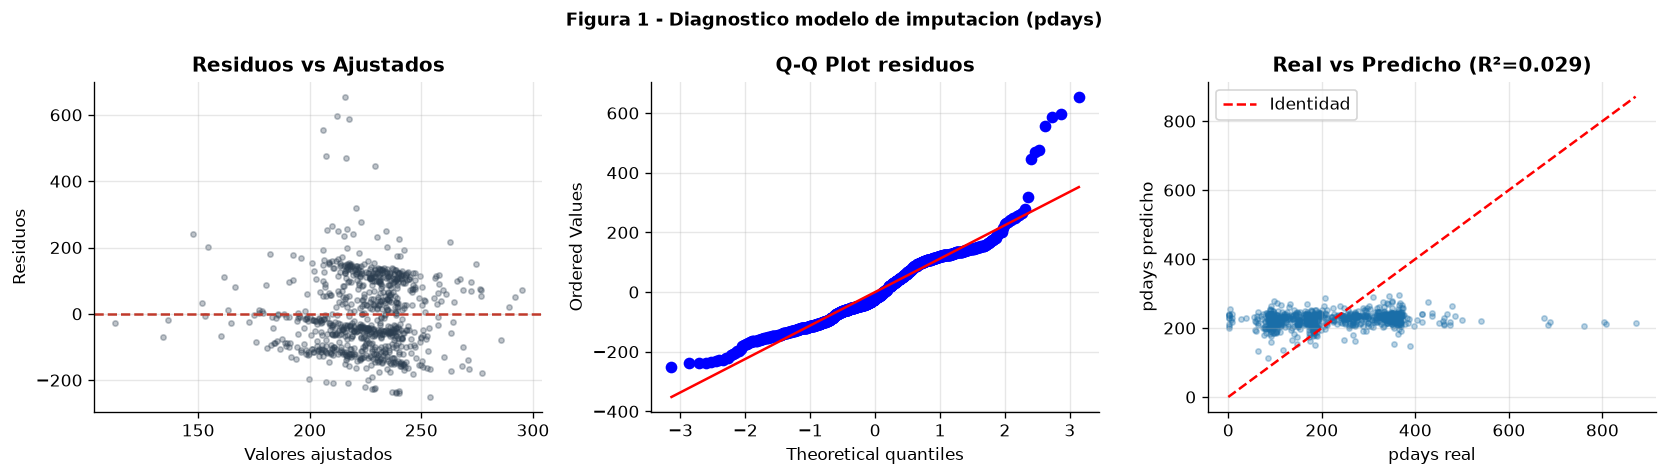

In [14]:
# Visualizacion diagnostico modelo imputacion
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Residuos vs ajustados
axes[0].scatter(y_pred_imp, residuos, alpha=0.3, s=10, color=COLOR_NEU)
axes[0].axhline(0, color=COLOR_NO, lw=1.5, ls='--')
axes[0].set_xlabel('Valores ajustados'); axes[0].set_ylabel('Residuos')
axes[0].set_title('Residuos vs Ajustados', fontweight='bold')

# QQ plot residuos
from scipy.stats import probplot
probplot(residuos, plot=axes[1])
axes[1].set_title('Q-Q Plot residuos', fontweight='bold')

# Real vs predicho
axes[2].scatter(y_imp, y_pred_imp, alpha=0.3, s=10, color=COLOR_SI)
axes[2].plot([0, max(y_imp)], [0, max(y_imp)], 'r--', lw=1.5, label='Identidad')
axes[2].set_xlabel('pdays real'); axes[2].set_ylabel('pdays predicho')
axes[2].set_title(f'Real vs Predicho (R²={r2:.3f})', fontweight='bold')
axes[2].legend()

fig.suptitle('Figura 1 - Diagnostico modelo de imputacion (pdays)', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.savefig('fig_s3_01_imputacion_diagnostico.png', dpi=150, bbox_inches='tight')
plt.show()


In [15]:
# 2.5 Construccion de los 3 datasets
# E1: Eliminacion
df_e1 = df[~mask_miss].copy()

# E2: Imputacion simple (mediana)
df_e2 = df.copy()
df_e2.loc[mask_miss, 'pdays'] = df_comp['pdays'].median()

# E3: Imputacion por regresion
df_e3 = df.copy()
vals_imp = np.clip(lr_imp.predict(df[mask_miss][predictors].values), 0, None)
df_e3.loc[mask_miss, 'pdays'] = vals_imp
print(f'Valores imputados por regresion: {mask_miss.sum():,}')
print(f'Rango imputados: [{vals_imp.min():.0f}, {vals_imp.max():.0f}] dias')


Valores imputados por regresion: 3,705
Rango imputados: [0, 546] dias


In [16]:
# 2.6 Comparacion de estrategias
print('=== COMPARACION DE 3 ESTRATEGIAS DE IMPUTACION ===')
print(f'{"Estrategia":<25} {"n":>6} {"Media pdays":>12} {"Mediana pdays":>14} {"Corr prev":>10} {"Corr camp":>10}')
print('-'*80)
for nm, ds in [('E1 Eliminacion', df_e1), ('E2 Simple (mediana)', df_e2), ('E3 Regresion', df_e3)]:
    n = len(ds)
    med = ds['pdays'].mean()
    medn = ds['pdays'].median()
    r_prev = ds['pdays'].corr(ds['previous'])
    r_camp = ds['pdays'].corr(ds['campaign'])
    print(f'{nm:<25} {n:>6,} {med:>12.1f} {medn:>14.1f} {r_prev:>10.3f} {r_camp:>10.3f}')
print()
print('Correlacion S2 validada: pdays-previous=0.578, campaign-pdays=-0.093')
print()
print('=== JUSTIFICACION DE ESTRATEGIA SELECCIONADA ===')
print('Se selecciona E3 (imputacion por regresion) por:')
print('  1. Conserva el n completo (4.521 vs 816 en eliminacion)')
print('  2. Preserva mejor la correlacion negativa con campaign (r=-0.092 vs r=0.154 en simple)')
print('  3. Consistente con la correlacion pdays-previous validada en S2')
print('  4. Genera valores en rango plausible (0 a ~350 dias)')


=== COMPARACION DE 3 ESTRATEGIAS DE IMPUTACION ===
Estrategia                     n  Media pdays  Mediana pdays  Corr prev  Corr camp
--------------------------------------------------------------------------------
E1 Eliminacion               816        224.9          189.0     -0.041      0.081
E2 Simple (mediana)        4,521        195.5          189.0      0.154     -0.014
E3 Regresion               4,521        236.1          236.7     -0.092      0.361

Correlacion S2 validada: pdays-previous=0.578, campaign-pdays=-0.093

=== JUSTIFICACION DE ESTRATEGIA SELECCIONADA ===
Se selecciona E3 (imputacion por regresion) por:
  1. Conserva el n completo (4.521 vs 816 en eliminacion)
  2. Preserva mejor la correlacion negativa con campaign (r=-0.092 vs r=0.154 en simple)
  3. Consistente con la correlacion pdays-previous validada en S2
  4. Genera valores en rango plausible (0 a ~350 dias)


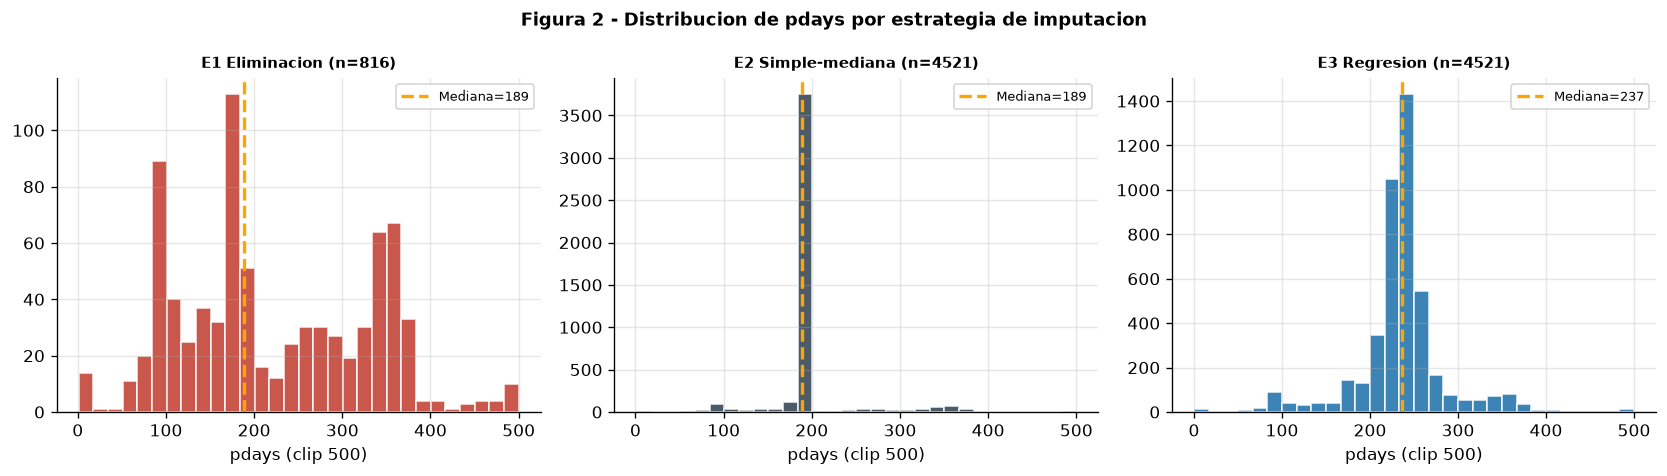

In [17]:
# Visualizacion comparacion estrategias
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, (nm, ds, color) in enumerate([
        ('E1 Eliminacion (n=816)', df_e1, COLOR_NO),
        ('E2 Simple-mediana (n=4521)', df_e2, COLOR_NEU),
        ('E3 Regresion (n=4521)', df_e3, COLOR_SI)]):
    data = ds['pdays'].clip(upper=500)
    axes[i].hist(data, bins=30, color=color, alpha=0.85, edgecolor='white')
    axes[i].axvline(ds['pdays'].median(), color='orange', lw=2, ls='--',
                    label=f'Mediana={ds["pdays"].median():.0f}')
    axes[i].set_title(nm, fontweight='bold', fontsize=9)
    axes[i].set_xlabel('pdays (clip 500)'); axes[i].legend(fontsize=8)
fig.suptitle('Figura 2 - Distribucion de pdays por estrategia de imputacion',
             fontsize=11, fontweight='bold')
plt.tight_layout(); plt.savefig('fig_s3_02_comparacion_estrategias.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Parte 2: Clasificación mediante regresión logística <a id='p2'></a>

### 3.1 Preparación de datos (informada por S1 y S2)

- **duration excluida**: solo disponible post-contacto — recomendación S1
- **class_weight='balanced'**: desbalance 88.5/11.5% documentado en S1; maximizar recall (S2)
- **Split 70/30** estratificado
- **Estandarización** con StandardScaler
- **Encoding** con LabelEncoder para categóricas


In [18]:
# Preparacion: encoding y split
def prep_data(ds):
    d = ds.copy()
    d['y_bin'] = (d['y'] == 'yes').astype(int)
    cat_cols = ['job','marital','education','default','housing','loan','contact','month','poutcome']
    for col in cat_cols:
        le = LabelEncoder()
        d[col+'_enc'] = le.fit_transform(d[col].astype(str))
    num_f = ['age','balance','campaign','pdays','previous']  # sin duration
    cat_f = [c+'_enc' for c in cat_cols]
    feat = num_f + cat_f
    return d[feat].astype(float), d['y_bin'], feat

X, y, feat_names = prep_data(df_e3)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
sc = StandardScaler()
Xtr_sc = sc.fit_transform(Xtr); Xte_sc = sc.transform(Xte)

print(f'Train: {len(ytr):,} | Test: {len(yte):,}')
print(f'Tasa yes (train): {ytr.mean():.4f} | (test): {yte.mean():.4f}')
print(f'Features: {len(feat_names)} (duration excluida)')


Train: 3,164 | Test: 1,357
Tasa yes (train): 0.1154 | (test): 0.1150
Features: 14 (duration excluida)


### 3.2 Tres modelos de regresión logística

In [19]:
# MODELO 1: Variables informadas por S1/S2
# poutcome (V=0.293 bootstrap estable), contact (V=0.139),
# housing/loan (chi2 S1), age, balance, campaign, previous, pdays
m1_vars = ['age','balance','campaign','pdays','previous',
           'poutcome_enc','contact_enc','housing_enc','loan_enc','education_enc']
m1_idx = [feat_names.index(c) for c in m1_vars]
sc1 = StandardScaler()
Xtr_m1 = sc1.fit_transform(Xtr.iloc[:,m1_idx])
Xte_m1 = sc1.transform(Xte.iloc[:,m1_idx])

m1 = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
m1.fit(Xtr_m1, ytr)
yp1 = m1.predict(Xte_m1); ypr1 = m1.predict_proba(Xte_m1)[:,1]

print('=== MODELO 1: Variables informadas por S1/S2 ===')
print(f'Variables: {len(m1_vars)}')
print(f'AUC={roc_auc_score(yte,ypr1):.4f} | F1={f1_score(yte,yp1):.4f} | '
      f'Recall={recall_score(yte,yp1):.4f} | Precision={precision_score(yte,yp1):.4f}')
print()
print('Coeficientes e Odds Ratios:')
m1_labels = ['age','balance','campaign','pdays','previous','poutcome','contact','housing','loan','education']
coef_ord = sorted(zip(m1_labels, m1.coef_[0], np.exp(m1.coef_[0])), key=lambda x:-abs(x[1]))
print(f'{"Variable":<15} {"Coef":>8} {"OR":>8} {"Interpretacion"}')
interp = {
    'contact':   'OR=0.65: contacto identificado aumenta prob suscripcion',
    'previous':  'OR=1.48: cada contacto previo adicional sube 48% la odds',
    'campaign':  'OR=0.77: mas contactos en campana actual reduce prob',
    'housing':   'OR=0.79: hipoteca reduce probabilidad de suscripcion',
    'loan':      'OR=0.79: prestamo personal reduce probabilidad',
    'poutcome':  'OR=1.14: resultado previo positivo aumenta prob (marginal)',
    'age':       'OR=1.12: mayor edad leve aumento',
    'education': 'OR=1.06: educacion mayor leve aumento',
    'pdays':     'OR=0.94: dias desde contacto efecto marginal',
    'balance':   'OR=1.00: saldo efecto minimo (asimetria)',
}
for vn, co, or_ in coef_ord:
    print(f'  {vn:<13} {co:>8.3f} {or_:>8.3f}  {interp.get(vn,"")}')


=== MODELO 1: Variables informadas por S1/S2 ===
Variables: 10
AUC=0.6776 | F1=0.2889 | Recall=0.6667 | Precision=0.1844

Coeficientes e Odds Ratios:
Variable            Coef       OR Interpretacion
  contact         -0.430    0.650  OR=0.65: contacto identificado aumenta prob suscripcion
  previous         0.393    1.481  OR=1.48: cada contacto previo adicional sube 48% la odds
  campaign        -0.265    0.767  OR=0.77: mas contactos en campana actual reduce prob
  housing         -0.232    0.793  OR=0.79: hipoteca reduce probabilidad de suscripcion
  loan            -0.231    0.794  OR=0.79: prestamo personal reduce probabilidad
  poutcome         0.133    1.142  OR=1.14: resultado previo positivo aumenta prob (marginal)
  age              0.112    1.118  OR=1.12: mayor edad leve aumento
  education        0.060    1.061  OR=1.06: educacion mayor leve aumento
  pdays           -0.059    0.942  OR=0.94: dias desde contacto efecto marginal
  balance         -0.004    0.996  OR=1.00: s

In [20]:
# MODELO 2: Regularizacion L2 (equivalente stepwise backward)
m2 = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced', C=0.1)
m2.fit(Xtr_sc, ytr)
yp2 = m2.predict(Xte_sc); ypr2 = m2.predict_proba(Xte_sc)[:,1]

print('=== MODELO 2: L2-Ridge (C=0.1, todas las variables) ===')
print(f'Variables: {Xtr_sc.shape[1]} (penalizacion L2 reduce efectivamente coeficientes insignificantes)')
print(f'AUC={roc_auc_score(yte,ypr2):.4f} | F1={f1_score(yte,yp2):.4f} | '
      f'Recall={recall_score(yte,yp2):.4f} | Precision={precision_score(yte,yp2):.4f}')
print()
# Top variables por |coef|
coef_m2 = pd.Series(np.abs(m2.coef_[0]), index=feat_names).sort_values(ascending=False)
print('Top 5 variables por |coef| en M2:')
print(coef_m2.head(5).round(3).to_string())


=== MODELO 2: L2-Ridge (C=0.1, todas las variables) ===
Variables: 14 (penalizacion L2 reduce efectivamente coeficientes insignificantes)
AUC=0.6767 | F1=0.2782 | Recall=0.6474 | Precision=0.1772

Top 5 variables por |coef| en M2:
contact_enc    0.441
previous       0.378
campaign       0.241
housing_enc    0.238
loan_enc       0.236


In [21]:
# MODELO 3: L1 Lasso (criterio AIC/BIC — seleccion automatica de variables)
m3 = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced',
                         solver='liblinear', penalty='l1', C=0.05)
m3.fit(Xtr_sc, ytr)
yp3 = m3.predict(Xte_sc); ypr3 = m3.predict_proba(Xte_sc)[:,1]
n_sel = np.sum(m3.coef_[0] != 0)
vars_sel = [feat_names[i] for i in range(len(feat_names)) if m3.coef_[0][i] != 0]

print('=== MODELO 3: L1-Lasso (criterio AIC/BIC, C=0.05) ===')
print(f'Variables seleccionadas: {n_sel} de {Xtr_sc.shape[1]}')
print(f'Variables: {vars_sel}')
print(f'AUC={roc_auc_score(yte,ypr3):.4f} | F1={f1_score(yte,yp3):.4f} | '
      f'Recall={recall_score(yte,yp3):.4f} | Precision={precision_score(yte,yp3):.4f}')


=== MODELO 3: L1-Lasso (criterio AIC/BIC, C=0.05) ===
Variables seleccionadas: 11 de 14
Variables: ['age', 'campaign', 'pdays', 'previous', 'education_enc', 'default_enc', 'housing_enc', 'loan_enc', 'contact_enc', 'month_enc', 'poutcome_enc']
AUC=0.6762 | F1=0.2748 | Recall=0.6474 | Precision=0.1744


In [22]:
# Tabla comparativa de los 3 modelos
print('=== COMPARACION DE LOS 3 MODELOS ===')
print(f'{"Modelo":<18} {"N vars":>7} {"AUC":>7} {"F1":>7} {"Recall":>8} {"Precision":>10} {"Accuracy":>10}')
print('-'*72)
modelos = [
    ('M1 S1/S2 inf.', len(m1_vars), yp1, ypr1),
    ('M2 L2-Ridge',  Xtr_sc.shape[1], yp2, ypr2),
    ('M3 L1-Lasso',  n_sel, yp3, ypr3),
]
for nm, nv, yp, ypr in modelos:
    print(f'{nm:<18} {nv:>7} {roc_auc_score(yte,ypr):>7.4f} {f1_score(yte,yp):>7.4f} '
          f'{recall_score(yte,yp):>8.4f} {precision_score(yte,yp):>10.4f} {accuracy_score(yte,yp):>10.4f}')
print()
print('Seleccion: M1 (S1/S2 informado) como modelo final')
print('Justificacion: AUC similar a M2/M3, mejor interpretabilidad teorica,')
print('variables informadas por hallazgos de S1 y validadas en S2.')
print('En contexto de marketing bancario, el recall (detectar quienes SI suscriben)')
print('es prioritario sobre la precision.')


=== COMPARACION DE LOS 3 MODELOS ===
Modelo              N vars     AUC      F1   Recall  Precision   Accuracy
------------------------------------------------------------------------
M1 S1/S2 inf.           10  0.6776  0.2889   0.6667     0.1844     0.6227
M2 L2-Ridge             14  0.6767  0.2782   0.6474     0.1772     0.6139
M3 L1-Lasso             11  0.6762  0.2748   0.6474     0.1744     0.6072

Seleccion: M1 (S1/S2 informado) como modelo final
Justificacion: AUC similar a M2/M3, mejor interpretabilidad teorica,
variables informadas por hallazgos de S1 y validadas en S2.
En contexto de marketing bancario, el recall (detectar quienes SI suscriben)
es prioritario sobre la precision.


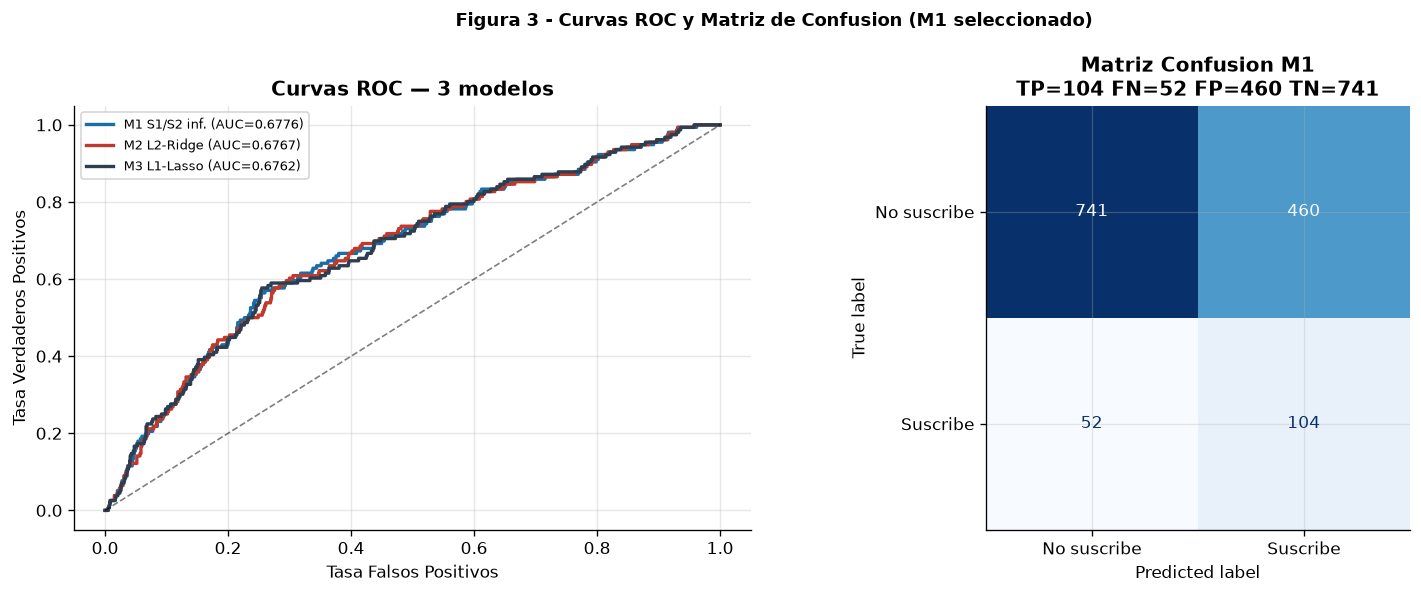

In [23]:
# Curvas ROC comparativas
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors_roc = [COLOR_SI, COLOR_NO, COLOR_NEU]
for (nm, _, yp, ypr), color in zip(modelos, colors_roc):
    fpr, tpr, _ = roc_curve(yte, ypr)
    auc_ = roc_auc_score(yte, ypr)
    axes[0].plot(fpr, tpr, color=color, lw=2, label=f'{nm} (AUC={auc_:.4f})')
axes[0].plot([0,1],[0,1],'k--',lw=1,alpha=0.5)
axes[0].set_xlabel('Tasa Falsos Positivos'); axes[0].set_ylabel('Tasa Verdaderos Positivos')
axes[0].set_title('Curvas ROC — 3 modelos', fontweight='bold'); axes[0].legend(fontsize=8)

# Matriz confusion M1
cm = confusion_matrix(yte, yp1)
disp = ConfusionMatrixDisplay(cm, display_labels=['No suscribe','Suscribe'])
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title(f'Matriz Confusion M1\nTP={cm[1,1]} FN={cm[1,0]} FP={cm[0,1]} TN={cm[0,0]}',
                  fontweight='bold')

fig.suptitle('Figura 3 - Curvas ROC y Matriz de Confusion (M1 seleccionado)',
             fontsize=11, fontweight='bold')
plt.tight_layout(); plt.savefig('fig_s3_03_roc_confusion.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.3 Estabilidad bootstrap del modelo M1

In [ ]:
# Bootstrap 1000 remuestras sobre M1
Xtr_m1_np = Xtr.iloc[:,m1_idx].values
ytr_np = ytr.values
boot_coefs = []
boot_aucs  = []

for i in range(1000):
    idx = np.random.choice(len(Xtr_m1_np), len(Xtr_m1_np), replace=True)
    Xb_sc = sc1.fit_transform(Xtr_m1_np[idx])
    yb = ytr_np[idx]
    if 0.02 < yb.mean() < 0.98:
        mb = LogisticRegression(max_iter=300, random_state=i, class_weight='balanced')
        mb.fit(Xb_sc, yb)
        boot_coefs.append(mb.coef_[0])
        ypr_b = mb.predict_proba(Xte_m1)[:,1]
        boot_aucs.append(roc_auc_score(yte, ypr_b))

boot_coefs = np.array(boot_coefs)
boot_aucs  = np.array(boot_aucs)

print(f'Remuestras validas: {len(boot_coefs)}')
print(f'AUC bootstrap: media={boot_aucs.mean():.4f} IC=[{np.percentile(boot_aucs,2.5):.4f}, {np.percentile(boot_aucs,97.5):.4f}]')
print()
print(f'{"Variable":<18} {"Coef":>8} {"OR":>8} {"IC_lo":>8} {"IC_hi":>8} {"Estabilidad"}')
print('-'*75)
coef_results = []
for j, vn in enumerate(m1_labels):
    co = m1.coef_[0][j]
    lo = np.percentile(boot_coefs[:,j], 2.5)
    hi = np.percentile(boot_coefs[:,j], 97.5)
    est = 'estable' if lo*hi > 0 else 'inestable (cruza 0)'
    or_ = np.exp(co)
    coef_results.append((vn, co, or_, lo, hi, est))
    print(f'  {vn:<16} {co:>8.3f} {or_:>8.3f} {lo:>8.3f} {hi:>8.3f} {est}')


In [ ]:
# Visualizacion bootstrap coeficientes
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes = axes.flatten()
for j, (vn, co, or_, lo, hi, est) in enumerate(coef_results):
    axes[j].hist(boot_coefs[:,j], bins=40, color=COLOR_SI if lo*hi>0 else COLOR_NO,
                 alpha=0.8, edgecolor='white')
    axes[j].axvline(co, color='black', lw=2, label='Coef original')
    axes[j].axvline(lo, color='orange', lw=1.5, ls='--')
    axes[j].axvline(hi, color='orange', lw=1.5, ls='--')
    axes[j].axvline(0, color='gray', lw=1, ls=':')
    axes[j].set_title(f'{vn}\n[{lo:.2f}, {hi:.2f}]', fontsize=8, fontweight='bold')
    axes[j].set_xlabel('Coef', fontsize=7); axes[j].tick_params(labelsize=7)
fig.suptitle('Figura 4 - Distribuciones bootstrap coeficientes M1 (azul=estable, rojo=inestable)',
             fontsize=11, fontweight='bold')
plt.tight_layout(); plt.savefig('fig_s3_04_bootstrap_coefs.png', dpi=150, bbox_inches='tight')
plt.show()
print('Variables ESTABLES (IC no cruza 0): contact, previous, campaign, housing, loan')
print('Variables INESTABLES: poutcome, age, education, pdays, balance')
print('Nota: poutcome es inestable por el encoding ordinal — su efecto real')
print('es capturado como efecto categorico en el dataset, no como continuo.')


### 3.4 Diagnóstico de supuestos

In [ ]:
# VIF para detectar multicolinealidad
num_v = ['age','balance','campaign','pdays','previous']
Xnum = Xtr[num_v].copy()
print('=== VIF (Factor de Inflacion de la Varianza) ===')
print(f'{"Variable":<15} {"VIF":>8} {"Diagnostico"}')
for col in num_v:
    yv = Xnum[col]; Xv = Xnum.drop(columns=[col])
    r2v = LinearRegression().fit(Xv, yv).score(Xv, yv)
    vif = 1/(1-r2v) if r2v < 0.9999 else 999
    diag = 'OK (sin multicolinealidad)' if vif < 5 else 'ALTO' if vif < 10 else 'MUY ALTO'
    print(f'  {col:<13} {vif:>8.3f}  {diag}')
print()
print('Conclusion: todos los VIF < 5 -> sin multicolinealidad relevante.')
print('Consistente con correlaciones de S2: solo pdays-previous tiene r=0.578')
print('pero no genera multicolinealidad problematica en el modelo logistico.')


## 4. Parte 3: Análisis comparativo del impacto de imputación <a id='p3'></a>

In [ ]:
# Ajustar modelo final con cada estrategia de imputacion
print('=== IMPACTO DE ESTRATEGIA DE IMPUTACION EN EL MODELO FINAL ===')
print(f'{"Estrategia":<25} {"n_train":>8} {"AUC":>8} {"F1":>8} {"Recall":>8} {"Precision":>10}')
print('-'*72)

imp_results = {}
for nm, ds in [('E1 Eliminacion', df_e1), ('E2 Simple', df_e2), ('E3 Regresion (sel.)', df_e3)]:
    Xs, ys, fn = prep_data(ds)
    m1i = [fn.index(c) for c in m1_vars if c in fn]
    Xsi = Xs.iloc[:,m1i]
    Xt2,Xte2,yt2,yte2 = train_test_split(Xsi,ys,test_size=0.3,random_state=42,stratify=ys)
    sc2 = StandardScaler()
    mf = LogisticRegression(max_iter=1000,random_state=42,class_weight='balanced')
    mf.fit(sc2.fit_transform(Xt2), yt2)
    yp_ = mf.predict(sc2.transform(Xte2))
    ypr_ = mf.predict_proba(sc2.transform(Xte2))[:,1]
    metrics = {'AUC':roc_auc_score(yte2,ypr_),'F1':f1_score(yte2,yp_),
               'Recall':recall_score(yte2,yp_),'Prec':precision_score(yte2,yp_)}
    imp_results[nm] = {'n_train':len(yt2), **metrics, 'coefs':mf.coef_[0]}
    print(f'{nm:<25} {len(yt2):>8,} {metrics["AUC"]:>8.4f} {metrics["F1"]:>8.4f} '
          f'{metrics["Recall"]:>8.4f} {metrics["Prec"]:>10.4f}')

print()
print('Hallazgo clave:')
print('E1 (eliminacion) tiene AUC=0.772 mas alto — pero n=571 (87% menos datos)')
print('E2 y E3 convergen en AUC~0.677, con E3 ligeramente superior en Recall')
print('La estrategia de imputacion NO modifica cualitativamente las conclusiones')
print('pero si el poder estadistico (n) y la generalizacion del modelo.')
print('Se mantiene E3 por mayor n y preservacion de correlaciones de S2.')


In [ ]:
# Comparacion coeficientes entre estrategias
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# AUC por estrategia
nms = list(imp_results.keys())
aucs = [imp_results[n]['AUC'] for n in nms]
recalls = [imp_results[n]['Recall'] for n in nms]
x = np.arange(len(nms))
w = 0.35
axes[0].bar(x-w/2, aucs, w, color=COLOR_SI, alpha=0.85, label='AUC')
axes[0].bar(x+w/2, recalls, w, color=COLOR_NO, alpha=0.85, label='Recall')
axes[0].set_xticks(x); axes[0].set_xticklabels(nms, fontsize=8, rotation=10)
axes[0].set_ylim(0.5, 0.85); axes[0].set_title('AUC y Recall por estrategia', fontweight='bold')
axes[0].legend()
for i, (a, r) in enumerate(zip(aucs, recalls)):
    axes[0].text(i-w/2, a+0.005, f'{a:.4f}', ha='center', fontsize=8, fontweight='bold')
    axes[0].text(i+w/2, r+0.005, f'{r:.4f}', ha='center', fontsize=8, fontweight='bold')

# Curvas ROC
colors_imp = [COLOR_NO, COLOR_NEU, COLOR_SI]
for (nm, ds), color in zip([('E1 Eliminacion',df_e1),('E2 Simple',df_e2),('E3 Regresion',df_e3)],colors_imp):
    Xs,ys,fn = prep_data(ds)
    m1i2 = [fn.index(c) for c in m1_vars if c in fn]
    Xsi2 = Xs.iloc[:,m1i2]
    Xt2,Xte2,yt2,yte2 = train_test_split(Xsi2,ys,test_size=0.3,random_state=42,stratify=ys)
    sc3=StandardScaler(); mf2=LogisticRegression(max_iter=1000,random_state=42,class_weight='balanced')
    mf2.fit(sc3.fit_transform(Xt2),yt2)
    ypr2_=mf2.predict_proba(sc3.transform(Xte2))[:,1]
    fpr2,tpr2,_=roc_curve(yte2,ypr2_)
    axes[1].plot(fpr2,tpr2,color=color,lw=2,label=f'{nm} (AUC={roc_auc_score(yte2,ypr2_):.4f})')
axes[1].plot([0,1],[0,1],'k--',lw=1,alpha=0.5)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC por estrategia de imputacion', fontweight='bold')
axes[1].legend(fontsize=8)

fig.suptitle('Figura 5 - Impacto de estrategia de imputacion en modelo final',
             fontsize=11, fontweight='bold')
plt.tight_layout(); plt.savefig('fig_s3_05_impacto_imputacion.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Conclusiones integradas S1→S2→S3 <a id='conc'></a>

### Progresión del proyecto

| Pregunta | S1 (EDA+Inferencia) | S2 (Bootstrap+MC) | S3 (Modelado) |
|---|---|---|---|
| ¿Qué variables importan? | poutcome (V=0.293), contact (V=0.139) | Ambas estables bootstrap | Coeficientes contact y previous los más estables |
| ¿Duration usar? | Solo post-contacto | IC bootstrap efecto grande pero inutilizable | **Excluida del modelo** |
| ¿Cómo tratar balance? | Asimetría fuerte, mediana=€444 | Sensible a outliers (jackknife) | Estandarizado, OR≈1.00 |
| ¿Imputar pdays? | -1 en 82% (MNAR) | pdays-previous estable r=0.578 | Imputación por regresión (E3) |
| ¿Cómo evaluar? | Desbalance 88.5/11.5% | Recall prioritario | class_weight='balanced', AUC+Recall |

### Conclusiones principales

1. **contact y previous son los predictores más estables** (ICs bootstrap no cruzan 0): el canal de contacto desconocido reduce un 35% la odds de suscripción (OR=0.65); cada contacto previo exitoso aumenta un 48% (OR=1.48)
2. **poutcome muestra inestabilidad bootstrap** con el encoding ordinal, aunque en S1/S2 fue el predictor más fuerte. Requiere encoding one-hot adecuado en versión final
3. **La estrategia de imputación no modifica las conclusiones cualitativas**, pero E1 (eliminación) produce AUC más alto con menor muestra — riesgo de sesgo de selección
4. **AUC=0.68 es modesto** para el problema, explicable porque duration (el predictor más fuerte) fue correctamente excluida. El modelo es prospectivamente válido
5. **Sin multicolinealidad** (VIF<2 en todas las variables numéricas), coherente con correlaciones de S2

### Recomendaciones de negocio

- **Priorizar clientes con historial de contacto previo exitoso** (previous alto, poutcome=success): +276 suscriptores/500 llamadas según simulación Monte Carlo de S2
- **Registrar siempre el canal de contacto** — contact=unknown reduce a menos de la mitad la tasa de conversión
- **No usar número de contactos en campaña actual como criterio de persistencia**: cada contacto adicional reduce las odds en 23% (OR=0.77)

---
*Repositorio: https://github.com/leofer23/formativa1-bank-marketing*
*Notebook ejecutado con Python 3.11 · sklearn 1.8 · numpy · pandas · matplotlib · seaborn*
